In [ ]:
!pip install transformers datasets evaluate --quiet
import pandas as pd
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback
import evaluate
import torch
import os
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import seaborn as sns
import json
from datetime import datetime
from sklearn.model_selection import train_test_split

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.1 MB/s eta 0:00:00


# USER INPUT CONFIGURATION

Specify which topic's dataset to evaluate with the variable 'gold_standard_topic'.

Options:
1.   environment
2.   health
3.   immigration


Select the model architecture to be used for fine-tuning or evaluation with the variable 'model_name'.
Options:
1. 'distilbert-base-uncased' — lighter, faster model
2. 'roberta-base' — larger model, typically more accurate but slower

Upload the dataset 'gold_standard_data.csv' when prompted.


In [ ]:
"""USER INPUT CONFIGURATION """

gold_standard_topic = 'environment'  # TODO: change as needed

model_name = "distilbert-base-uncased"  # TODO: change as needed

# Upload the dataset (named `gold_standard_data.csv`).
uploaded = files.upload()


# Helper Functions

In [ ]:
def compute_metrics(eval_pred):
    """
    Compute evaluation metrics for a multi-class classification task.
    Returns overall accuracy and class-wise precision, recall, F1-score, and support.

    Args:
        eval_pred: tuple (logits, labels)
            logits: model raw predictions
            labels: ground truth labels

    Returns:
        dict: metrics dictionary with overall accuracy and class-wise metrics
    """
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    # Compute overall accuracy
    acc = accuracy_score(labels, preds)

    # Compute class-wise metrics
    precision, recall, f1, support = precision_recall_fscore_support(
        labels,
        preds,
        average=None,
        zero_division=0
    )

    metrics = {"accuracy": acc}

    # Map numeric class indices to label names
    class_names = list(id2label.values())
    for i, cls in enumerate(class_names):
        metrics[f"{cls}_precision"] = precision[i]
        metrics[f"{cls}_recall"] = recall[i]
        metrics[f"{cls}_f1"] = f1[i]
        metrics[f"{cls}_support"] = support[i]

    return metrics

def save_metrics_to_file(metrics_dict, filename, description=""):
    """
    Save metrics to both JSON and human-readable text file with timestamp.

    Args:
        metrics_dict: dictionary of metrics
        filename: base filename (without extension)
        description: optional string description of metrics
    """
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    # Save as JSON
    json_filename = f"{filename}_{timestamp}.json"
    with open(json_filename, 'w') as f:
        json.dump(metrics_dict, f, indent=2)

    # Save as readable text
    txt_filename = f"{filename}_{timestamp}.txt"
    with open(txt_filename, 'w') as f:
        f.write(f"{description}\n")
        f.write("="*50 + "\n")
        for key, value in metrics_dict.items():
            f.write(f"{key}: {value}\n")

    print(f"Metrics saved to {json_filename} and {txt_filename}")


def plot_learning_curves(history_df):
    """
    Plot training loss and validation accuracy over epochs.

    Args:
        history_df: pandas DataFrame containing 'epoch', 'loss', and 'eval_accuracy'
    """

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot training loss
    train_loss = history_df[history_df['loss'].notna()][['epoch', 'loss']]
    axes[0].plot(train_loss['epoch'], train_loss['loss'], marker='o', label='Train Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training Loss Over Time')
    axes[0].legend()
    axes[0].grid(True)

    # PLot validation accuracy
    eval_acc = history_df[history_df['eval_accuracy'].notna()][['epoch', 'eval_accuracy']]
    if not eval_acc.empty:
        axes[1].plot(eval_acc['epoch'], eval_acc['eval_accuracy'],
                    marker='s', label='Validation Accuracy', color='green')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Accuracy')
        axes[1].set_title('Validation Accuracy Over Time')
        axes[1].legend()
        axes[1].grid(True)

    plt.tight_layout()
    plt.savefig('learning_curves.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Learning curves saved to learning_curves.png")


    def create_binary_confusion_matrix(y_true, y_pred, positive_class_idx, class_name):
    """
    Create a one-vs-rest binary confusion matrix for a specific class.

    Args:
        y_true: true labels (integer-encoded)
        y_pred: predicted labels (integer-encoded)
        positive_class_idx: index of the positive class
        class_name: class name string

    Returns:
        dict: confusion matrix metrics including TP, TN, FP, FN, accuracy, precision, recall, specificity, F1
    """

    # Convert to binary: positive class vs rest
    y_true_binary = (y_true == positive_class_idx).astype(int)
    y_pred_binary = (y_pred == positive_class_idx).astype(int)

    # Calculate confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_true_binary, y_pred_binary).ravel()

    # Calculate metrics
    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return {
        'class': class_name,
        'TP': tp,
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'specificity': specificity,
        'f1': f1
    }



def plot_binary_confusion_matrix(cm_dict, ax, cmap='Blues'):
    """
    Plot a single 2x2 binary confusion matrix.

    Args:
        cm_dict: dictionary with TP, TN, FP, FN, metrics, and class name
        ax: matplotlib axis to plot on
        cmap: colormap name
    """
    # Create 2x2 matrix
    cm = np.array([[cm_dict['TN'], cm_dict['FP']],
                   [cm_dict['FN'], cm_dict['TP']]])

    # Plot heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                cbar=False, square=True, linewidths=2, linecolor='black',
                annot_kws={'size': 14, 'weight': 'bold'})

    # Label axes
    ax.set_xlabel('Predicted', fontsize=11, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=11, fontweight='bold')
    ax.set_xticklabels(['Negative\n(Other)', 'Positive\n' + cm_dict['class']],
                       fontsize=9)
    ax.set_yticklabels(['Negative\n(Other)', 'Positive\n' + cm_dict['class']],
                       fontsize=9, rotation=0)

    # Add metrics in title
    title = f"{cm_dict['class']}\n"
    title += f"Acc: {cm_dict['accuracy']:.3f} | "
    title += f"Prec: {cm_dict['precision']:.3f} | "
    title += f"Rec: {cm_dict['recall']:.3f}\n"
    title += f"F1: {cm_dict['f1']:.3f} | "
    title += f"Spec: {cm_dict['specificity']:.3f}"
    ax.set_title(title, fontsize=10, fontweight='bold', pad=10)

def plot_all_binary_confusion_matrices(labels, preds, id2label):
    """
    Create and plot one-vs-rest binary confusion matrices for all classes.

    Args:
        labels: true labels array
        preds: predicted labels array
        id2label: dictionary mapping label indices to names

    Returns:
        list of metrics dictionaries for all classes
    """
    class_names = list(id2label.values())
    num_classes = len(class_names)

    # Calculate grid dimensions
    cols = min(3, num_classes)  # Maximum 3 columns
    rows = (num_classes + cols - 1) // cols  # Ceiling division

    # Create figure
    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 5*rows))
    fig.suptitle('Binary Confusion Matrices (One-vs-Rest)',
                 fontsize=16, fontweight='bold', y=0.995)

    # Flatten axes array for easier iteration
    if num_classes == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if num_classes > 1 else [axes]

    # Store results for summary
    results = []

    # Create binary confusion matrix for each class
    for idx, class_name in enumerate(class_names):
        cm_dict = create_binary_confusion_matrix(labels, preds, idx, class_name)
        results.append(cm_dict)

        # Plot
        plot_binary_confusion_matrix(cm_dict, axes[idx])

    # Hide unused subplots
    for idx in range(num_classes, len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.savefig('binary_confusion_matrices_all.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\nBinary confusion matrices saved to 'binary_confusion_matrices_all.png'")

    return results

def save_binary_cm_summary(results):
    """
    Save one-vs-rest binary confusion matrix metrics to CSV files.

    Args:
        results: list of dictionaries returned by create_binary_confusion_matrix
    Returns:
        pandas DataFrame of summary metrics
    """

    # Create summary DataFrame
    summary_df = pd.DataFrame(results)
    summary_df = summary_df[['class', 'TP', 'FP', 'TN', 'FN',
                             'accuracy', 'precision', 'recall',
                             'specificity', 'f1']]

    summary_df.to_csv('binary_confusion_matrices_summary.csv', index=False)
    print("\nBinary CM summary saved to 'binary_confusion_matrices_summary.csv'")

    # Save individual class confusion matrix CSVs
    for result in results:
        class_name = result['class'].replace('/', '_').replace(' ', '_')
        cm_data = {
            'Metric': ['True Negative', 'False Positive', 'False Negative', 'True Positive'],
            'Value': [result['TN'], result['FP'], result['FN'], result['TP']]
        }
        cm_df = pd.DataFrame(cm_data)
        cm_df.to_csv(f'binary_cm_{class_name}.csv', index=False)

    print(f"Individual binary CMs saved for each class")

    return summary_df

# Dataset Set Up

In [ ]:
# Load your CSV
df = pd.read_csv("gold_standard_data.csv")
df = df[df["topic"] == gold_standard_topic]

# Label mapping
labels = sorted(df["assigned_label"].unique())
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for label, i in label2id.items()}
print("\nlabel2id:", label2id)

# Convert to Hugging Face dataset
dataset = Dataset.from_pandas(df)

Saving gold_standard_data.csv to gold_standard_data.csv
Original class distribution:
assigned_label
belief        100
fact-check    100
other         100
Name: count, dtype: int64

label2id: {'belief': 0, 'fact-check': 1, 'other': 2}


In [ ]:
""" STRATIFIED TRAIN/VAL/TEST SPLIT (70/15/15)

1. Split dataset into training (70%) and temporary (30%) sets.
   Stratified sampling ensures that the class distribution in each subset
   matches the overall dataset distribution, preventing class imbalance.

2. Split the temporary set into validation (15%) and test (15%).
   The temp set (30%) is evenly divided into validation and test sets (15% each),
   again using stratification for balanced class distribution

"""

# First split: 70% train, 30% temp
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    random_state=42,
    stratify=df['assigned_label']
)

# Second split: Split the 30% into 15% validation and 15% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df['assigned_label']
)


Dataset sizes:
Train: 210 (70.0%)
Validation: 45 (15.0%)
Test: 45 (15.0%)

Class distribution verification:

Train:
  other: 70 (33.3%)
  fact-check: 70 (33.3%)
  belief: 70 (33.3%)

Validation:
  belief: 15 (33.3%)
  other: 15 (33.3%)
  fact-check: 15 (33.3%)

Test:
  fact-check: 15 (33.3%)
  other: 15 (33.3%)
  belief: 15 (33.3%)


Map:   0%|          | 0/210 [00:00<?, ? examples/s]

Map:   0%|          | 0/45 [00:00<?, ? examples/s]

Map:   0%|          | 0/45 [00:00<?, ? examples/s]

Map:   0%|          | 0/210 [00:00<?, ? examples/s]

Map:   0%|          | 0/45 [00:00<?, ? examples/s]

Map:   0%|          | 0/45 [00:00<?, ? examples/s]


First training sample:
{'id': 206, 'topic': 'environment', 'assigned_label': 'other', 'comment': 'I wonder what their opinion is on Palestine?', '__index_level_0__': 205, 'input_ids': [0, 100, 5170, 99, 49, 2979, 16, 15, 16398, 116, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


# Model Set Up

In [ ]:
# Convert to Hugging Face datasets to be used with the Transformers Trainer API
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

""" Tokenize text data """
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize(batch):
    """
    Converts text to token IDs understood by the model.
    Uses max_length padding and truncation to handle variable-length inputs.
    """
    return tokenizer([str(x) for x in batch["comment"]], padding="max_length", truncation=True)

#  Apply tokenization to all dataset splits in batches
train_encoded = train_dataset.map(tokenize, batched=True)
val_encoded = val_dataset.map(tokenize, batched=True)
test_encoded = test_dataset.map(tokenize, batched=True)

""" Encode labels """
# Map string labels to integers
def encode_labels(batch):
    return {"labels": [label2id[str(l)] for l in batch["assigned_label"]]}

# Apply label encoding to all splits.
train_encoded = train_encoded.map(encode_labels, batched=True)
val_encoded = val_encoded.map(encode_labels, batched=True)
test_encoded = test_encoded.map(encode_labels, batched=True)


""" Load the pre-trained transformer model """
num_labels = len(labels)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

# Training

/tmp/ipython-input-2166023011.py:20: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(



TRAINING PHASE


Epoch,Training Loss,Validation Loss,Accuracy,Belief Precision,Belief Recall,Belief F1,Belief Support,Fact-check Precision,Fact-check Recall,Fact-check F1,Fact-check Support,Other Precision,Other Recall,Other F1,Other Support
1,1.093700,1.078361,0.533333,0.444444,0.800000,0.571429,15,0.692308,0.600000,0.642857,15,0.600000,0.200000,0.300000,15
2,0.942400,0.872263,0.688889,0.857143,0.400000,0.545455,15,0.722222,0.866667,0.787879,15,0.600000,0.800000,0.685714,15
3,0.618300,0.718355,0.622222,1.000000,0.066667,0.125000,15,0.812500,0.866667,0.838710,15,0.500000,0.933333,0.651163,15
4,0.539600,0.691165,0.688889,0.714286,0.333333,0.454545,15,0.928571,0.866667,0.896552,15,0.541667,0.866667,0.666667,15


Training history saved to training_history.csv


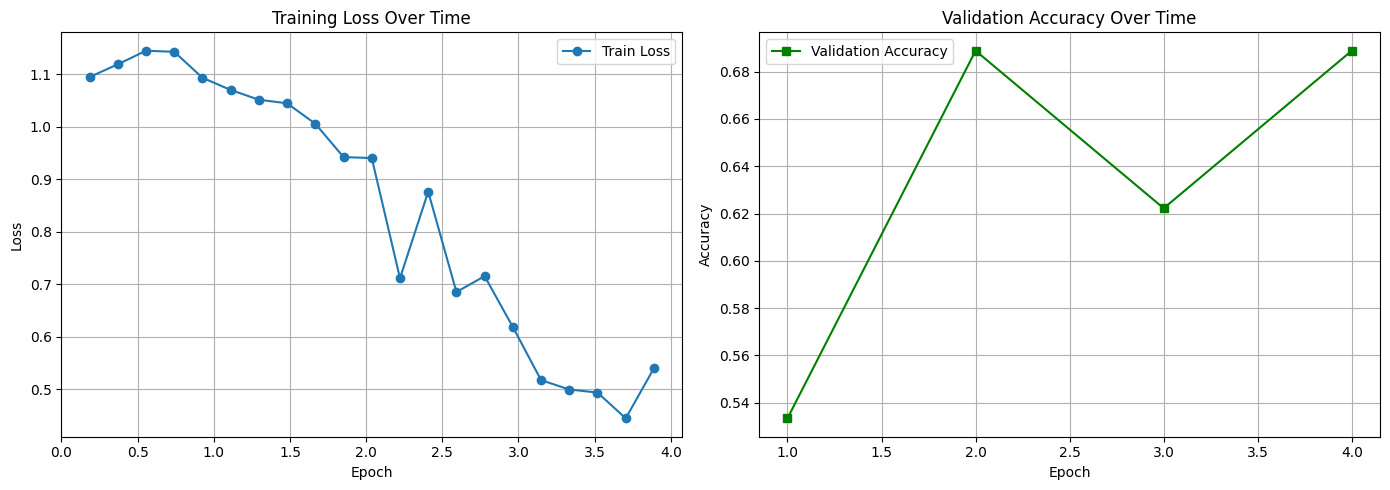

Learning curves saved to learning_curves.png

Best model checkpoint: ./results/checkpoint-54
Best metric (accuracy): 0.6888888888888889


In [ ]:
""" Training arguments configuration"""

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",                # Evaluate the model after every epoch
    save_strategy="epoch",                # Save checkpoints at the end of each epoch
    load_best_model_at_end=True,          # Automatically load the best model (based on eval metric) at the end
    metric_for_best_model="accuracy",     # Metric used to determine the best model
    learning_rate=2e-5,                   # Standard fine-tuning learning rate for transformer models
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=10,                  # Maximum number of training epochs
    weight_decay=0.01,                    # Apply L2 regularization to prevent overfitting
    logging_dir="./logs",
    logging_steps=5,                      # Log metrics every 5 training steps
)

""" Initalise trainer """

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_encoded,
    eval_dataset=val_encoded,             # Validation dataset (used for early stopping)
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,      # Custom defined function to compute accuracy, precision, recall, F1, etc.
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
        # Early stopping: stop training if performance doesn’t improve after 2 evaluation rounds
)

""" Train """
trainer.train()

""" Save Training History """

# Extract training history from trainer
train_history = trainer.state.log_history

# Save the training log as a CSV file and JSON file
history_df = pd.DataFrame(train_history)
history_df.to_csv("training_history.csv", index=False)
print("Training history saved to training_history.csv")

with open("training_history.json", 'w') as f:
    json.dump(train_history, f, indent=2)

# Plot training loss and validation accuracy across epochs using function.
plot_learning_curves(history_df)

# Identify and display the best checkpoint directory (based on metric_for_best_model)
best_epoch = trainer.state.best_model_checkpoint
print(f"\nBest model checkpoint: {best_epoch}")
print(f"Best metric ({training_args.metric_for_best_model}): {trainer.state.best_metric}")

# Validation Set

In [ ]:
""" Evaluate on Validation Set """

print("\n" + "="*50)
print("VALIDATION SET RESULTS")
print("="*50)
val_metrics = trainer.evaluate(val_encoded)
print(val_metrics)

# Save results to CSV
save_metrics_to_file(val_metrics, "validation_metrics", "VALIDATION SET RESULTS")


VALIDATION SET RESULTS


{'eval_loss': 0.8722630143165588, 'eval_accuracy': 0.6888888888888889, 'eval_belief_precision': 0.8571428571428571, 'eval_belief_recall': 0.4, 'eval_belief_f1': 0.5454545454545454, 'eval_belief_support': 15, 'eval_fact-check_precision': 0.7222222222222222, 'eval_fact-check_recall': 0.8666666666666667, 'eval_fact-check_f1': 0.7878787878787878, 'eval_fact-check_support': 15, 'eval_other_precision': 0.6, 'eval_other_recall': 0.8, 'eval_other_f1': 0.6857142857142857, 'eval_other_support': 15, 'eval_runtime': 1.2782, 'eval_samples_per_second': 35.205, 'eval_steps_per_second': 4.694, 'epoch': 4.0}
Metrics saved to validation_metrics_20251102_053312.json and validation_metrics_20251102_053312.txt


# Test Set

In [ ]:
""" Evaluate on Test Set """

print("\n" + "="*50)
print("TEST SET RESULTS (FINAL METRICS)")
print("="*50)
test_predictions = trainer.predict(test_encoded)
test_metrics = test_predictions.metrics
print(test_metrics)

# Get predictions and labels
preds = np.argmax(test_predictions.predictions, axis=-1)
labels = test_predictions.label_ids

# Print detailed classification report
print("\nDetailed Classification Report (Test Set):")
class_names = list(id2label.values())
print(classification_report(labels, preds, target_names=class_names, zero_division=0))

# After test evaluation
save_metrics_to_file(test_metrics, "test_metrics", "TEST SET RESULTS")

# Save classification report to file
report_dict = classification_report(labels, preds, target_names=class_names,
                                   zero_division=0, output_dict=True)
save_metrics_to_file(report_dict, "classification_report", "DETAILED CLASSIFICATION REPORT")


TEST SET RESULTS (FINAL METRICS)


{'test_loss': 0.8971045613288879, 'test_accuracy': 0.6, 'test_belief_precision': 0.8333333333333334, 'test_belief_recall': 0.3333333333333333, 'test_belief_f1': 0.47619047619047616, 'test_belief_support': 15, 'test_fact-check_precision': 0.6470588235294118, 'test_fact-check_recall': 0.7333333333333333, 'test_fact-check_f1': 0.6875, 'test_fact-check_support': 15, 'test_other_precision': 0.5, 'test_other_recall': 0.7333333333333333, 'test_other_f1': 0.5945945945945946, 'test_other_support': 15, 'test_runtime': 1.2173, 'test_samples_per_second': 36.967, 'test_steps_per_second': 4.929}

Detailed Classification Report (Test Set):
              precision    recall  f1-score   support

      belief       0.83      0.33      0.48        15
  fact-check       0.65      0.73      0.69        15
       other       0.50      0.73      0.59        15

    accuracy                           0.60        45
   macro avg       0.66      0.60      0.59        45
weighted avg       0.66      0.60      0.

# Generate plots and results from test set

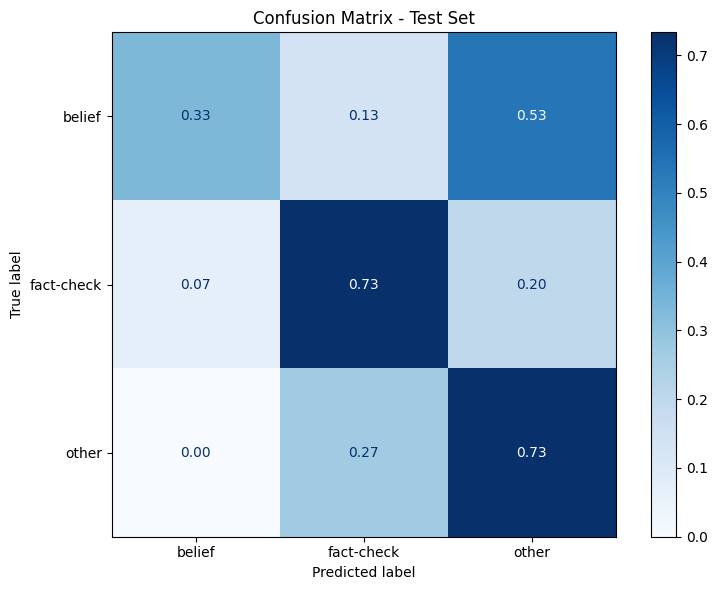

Confusion matrix saved to confusion_matrix_normalized.csv


In [ ]:
""" Generate multi-dimensional confusion matrix """
cm = confusion_matrix(labels, preds, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=True, values_format='.2f')
plt.title("Confusion Matrix - Test Set")
plt.tight_layout()
plt.show()

# 4. Save confusion matrix as CSV
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
cm_df.to_csv('confusion_matrix_normalized.csv')
print("Confusion matrix saved to confusion_matrix_normalized.csv")

In [ ]:
""" Find errors in classification and save to CSV """
misclassified_indices = np.where(preds != labels)[0]
if len(misclassified_indices) > 0:
    error_analysis = []
    for idx in misclassified_indices[:50]:  # Save first 50 errors
        error_analysis.append({
            'text': test_df.iloc[idx]['comment'],
            'true_label': id2label[labels[idx]],
            'predicted_label': id2label[preds[idx]],
            'confidence': np.max(test_predictions.predictions[idx])
        })

    error_df = pd.DataFrame(error_analysis)
    error_df.to_csv('error_analysis.csv', index=False)
    print(f"Error analysis saved to error_analysis.csv ({len(misclassified_indices)} total errors)")

Error analysis saved to error_analysis.csv (18 total errors)



BINARY CONFUSION MATRICES (ONE-VS-REST)

belief (One-vs-Rest):
  TP:    5  |  FP:    1
  FN:   10  |  TN:   29
  Accuracy:    0.7556
  Precision:   0.8333
  Recall:      0.3333
  Specificity: 0.9667
  F1-Score:    0.4762

fact-check (One-vs-Rest):
  TP:   11  |  FP:    6
  FN:    4  |  TN:   24
  Accuracy:    0.7778
  Precision:   0.6471
  Recall:      0.7333
  Specificity: 0.8000
  F1-Score:    0.6875

other (One-vs-Rest):
  TP:   11  |  FP:   11
  FN:    4  |  TN:   19
  Accuracy:    0.6667
  Precision:   0.5000
  Recall:      0.7333
  Specificity: 0.6333
  F1-Score:    0.5946


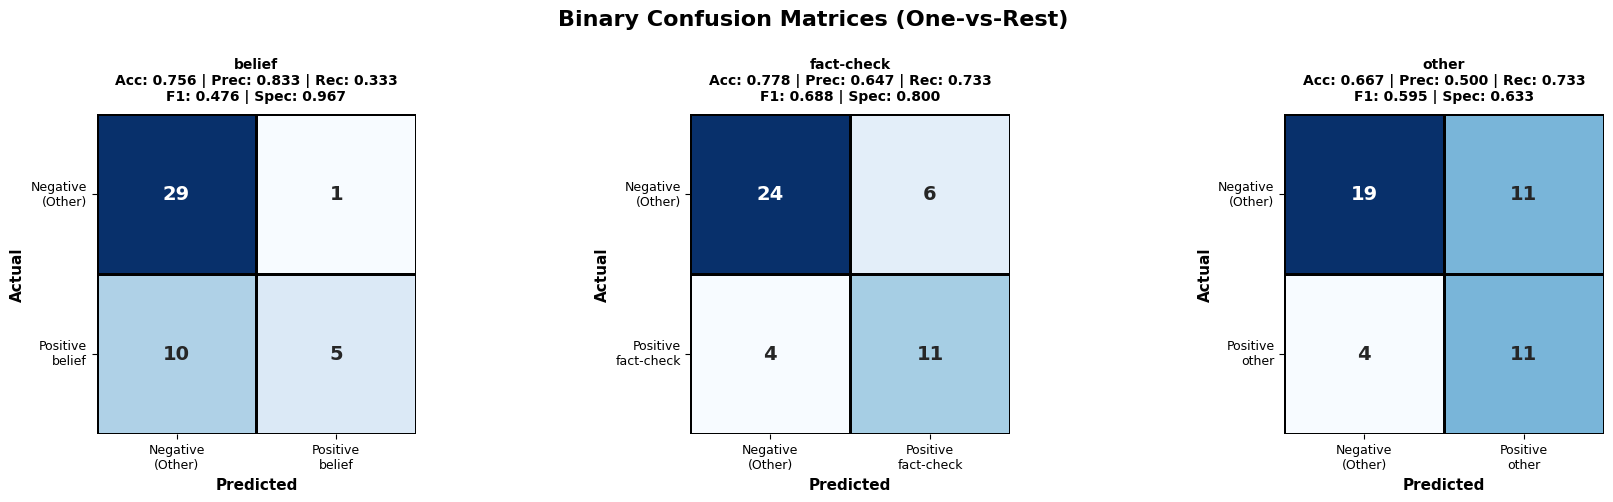


Binary confusion matrices saved to 'binary_confusion_matrices_all.png'

Binary CM summary saved to 'binary_confusion_matrices_summary.csv'
Individual binary CMs saved for each class

SUMMARY TABLE
     class  TP  FP  TN  FN  accuracy  precision   recall  specificity       f1
    belief   5   1  29  10  0.755556   0.833333 0.333333     0.966667 0.476190
fact-check  11   6  24   4  0.777778   0.647059 0.733333     0.800000 0.687500
     other  11  11  19   4  0.666667   0.500000 0.733333     0.633333 0.594595


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
""" Create and plot all binary confusion matrices """
binary_results = plot_all_binary_confusion_matrices(labels, preds, id2label)

""" Save summary """
summary_df = save_binary_cm_summary(binary_results)